# Line versus Word Qwen performance

In [187]:
!pip install pytesseract
!pip install rapidfuzz

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Doctr and line creation algorithm

In [2]:
# see doctr_line_algorithm notebook for the original code
# This script is a modified version of the original

import cv2 as cv
import numpy as np
from doctr.models import detection_predictor
import matplotlib.pyplot as plt

image = cv.imread("/home/bas/Documents/Visual Code Repo's/BelHisFirm-BelHisHAAI/experiments/test/test-Yves_026_None.png", cv.IMREAD_COLOR)

def warp_function(image):
    gray = image if image.ndim == 2 else cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    edges = cv.Canny(gray, 50, 150, apertureSize=3)
    lines = cv.HoughLinesP(edges, 1, np.pi/180, threshold=100,
                           minLineLength=100, maxLineGap=10)

    angles = []
    if lines is not None:
        for x1, y1, x2, y2 in lines[:, 0, :]:
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
            angles.append(angle)

    if not angles:
        return image

    median_angle = float(np.median(angles))

    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv.getRotationMatrix2D(center, median_angle, 1.0).astype(np.float32)

    rotated = cv.warpAffine(
        image, M, (w, h),
        flags=cv.INTER_CUBIC,
        borderMode=cv.BORDER_REPLICATE
    )
    return rotated

image = warp_function(image)

model = detection_predictor('db_resnet50', pretrained=True, assume_straight_pages=False, preserve_aspect_ratio=True)

out = model([image])
words_array = out[0]['words']


In [124]:
class BoxtoLine:

    def __init__(self):
        self.bbox_list = []
        self.line_bbox_list = []

    @staticmethod
    def clamp_box(x0, y0, x1, y1):
            x0, x1 = sorted([x0, x1])
            y0, y1 = sorted([y0, y1])
            return x0, y0, x1, y1
    
    @staticmethod
    def vert_iou_calc(bbox1, bbox2):
        x1, y1, x2, y2 = bbox1
        x3, y3, x4, y4 = bbox2

        if x1 <= x3 and x2 >= x4 and y1 <= y3 and y2 >= y4:
            return 1.0
        else:
            inter_w = max(0.0, 0.1)
            inter_h = max(0.0, min(y2, y4) - max(y1, y3))

            inter = inter_w * inter_h

            area_a = max(0.0, (0.1) * max(0.0, (y2 - y1)))
            area_b = max(0.0, (0.1) * max(0.0, (y4 - y3)))

            union = area_a + area_b - inter

            return inter / union 
    
    @staticmethod
    def resolve_bbox(bbox1, bbox2):

        x1, y1, x2, y2 = bbox1
        x3, y3, x4, y4 = bbox2
        bbox3 = (min(x1, x3), min(y1, y3), max(x2, x4), max(y2, y4))

        return bbox3

    def transform_boxes_to_line(self, words_array): 
        # restructure
        self.bbox_list = [(box[0][0], box[0][1], box[2][0], box[2][1]) for box in words_array]
        # clamp boxes
        self.bbox_list = [self.clamp_box(x0, y0, x1, y1) for (x0, y0, x1, y1) in self.bbox_list]
        # purge small boxes
        self.bbox_list = [box for box in self.bbox_list if (box[2] - box[0]) > 0.01 or (box[3] - box[1]) > 0.01]
        # Sort by vertical position and then horizontal position (halfway point)
        restructured_bbox_list = self.bbox_list.copy()
        restructured_bbox_list.sort(key=lambda b: (0.5*(b[1]+b[3]), b[0]))
        # Sort by horizontal position for later use
        self.bbox_list.sort(key=lambda b: (b[1], b[0]))

        word_counter = 0
        

        for idx, bbox in enumerate(restructured_bbox_list):
            if idx == 0:
                line = bbox
                word_counter = 1
                continue
            iou = self.vert_iou_calc(line, bbox)
            if iou > 0.5:
                word_counter += 1
                line = self.resolve_bbox(line, bbox)
            else:
                self.line_bbox_list.append((line, word_counter))
                line = bbox
                word_counter = 1

        self.line_bbox_list.append((line, word_counter)) 


# Create an instance of the class and transform the boxes
box_to_line = BoxtoLine()
box_to_line.transform_boxes_to_line(words_array)

bbox_list = box_to_line.bbox_list

line_list = box_to_line.line_bbox_list

In [198]:
import pytesseract
import matplotlib.pyplot as plt

def prepare_words_for_line_matching(line_list, bbox_list, image):

    # The purpose of this function is to create lines of text using Tesseract OCR.
    # It takes a list 'individual' words and their bounding boxes, the resolved lines and the image
    # That way I know which words belong to which line and I can use this to match the lines Qwen outputs to the actual words in the image. 
    # It uses the individual word bbox, which makes it a bit more complex, but it should be more accurate.

    h, w = image.shape[:2]
    total_words_counted = 0
    tesseract_transcribed_lines = []
    cropped_images_per_line = []

    for line in line_list:

        words_in_line = line[1]
        in_loop_word_counter = 0
        line_of_tesseract_transcription = []
        store_bbox = []

        while in_loop_word_counter < words_in_line:
            box = bbox_list[total_words_counted]
            # Extract these pairs
            h, w = image.shape[:2]
            x1 = int(box[0] * w)
            y1 = int(box[1] * h)
            x2 = int(box[2] * w)
            y2 = int(box[3] * h)

            store_bbox.append((x1, y1, x2, y2))

            in_loop_word_counter += 1
            total_words_counted += 1

        
        # Sort the store_bbox by x1 (leftmost coordinate)
        store_bbox.sort(key=lambda b: b[0])
        cropped_images_of_line = []

        for box in store_bbox:
            x1 = int(box[0])
            y1 = int(box[1])
            x2 = int(box[2])
            y2 = int(box[3])

            # Normalization
            crop = image[y1:y2, x1:x2]

            # Use pytesseract to extract text from the cropped image
            text = pytesseract.image_to_string(crop, config='--psm 8', lang='fra')
            # Append the cropped image to the list
            cropped_images_of_line.append(crop)

            if not line_of_tesseract_transcription:
                line_of_tesseract_transcription = [(text.strip(), box)]
            else:
                line_of_tesseract_transcription.append((text.strip(), box))

        # Append the line of transcription to the list
        print(line_of_tesseract_transcription)
        tesseract_transcribed_lines.append(line_of_tesseract_transcription)
        cropped_images_per_line.append(cropped_images_of_line)

    return tesseract_transcribed_lines, cropped_images_per_line

tesseract_transcribed_texts, cropped_images = prepare_words_for_line_matching(line_list, bbox_list, image)

[('382', (468, 334, 586, 406)), ('RECUKIL', (1065, 339, 1275, 390)), ('SPÉCIAL', (1288, 317, 1494, 397)), ('DES', (1517, 334, 1610, 385)), ('ACTES', (1635, 329, 1784, 380)), ('‘ET', (1805, 329, 1882, 380)), ('DOCUMENTS', (1903, 329, 2185, 375)), ('RELATIFS', (2216, 329, 2443, 375)), ('"AUX', (2468, 323, 2571, 375)), ('SOCTÉTÉE.', (2597, 318, 2833, 370))]
[('Mnounement', (1615, 565, 1872, 611)), ('du', (1898, 560, 1964, 616)), ('portefeuille', (1964, 560, 2257, 627))]
[('Il existait', (556, 678, 761, 745)), ('en', (761, 683, 828, 740)), ('portefeuille,', (828, 678, 1085, 745)), ('au', (1090, 683, 1162, 735)), ('51', (1157, 678, 1224, 735)), ('décembre', (1239, 678, 1440, 724)), ('4882,', (1450, 673, 1579, 724)), ('2.399', (2206, 668, 2345, 719)), ('effets,', (2355, 658, 2499, 724)), ('ensemble', (2509, 663, 2710, 714)), ('fr.', (2859, 673, 2921, 719)), ('755.677', (3096, 668, 3281, 719)), ('159', (3270, 668, 3353, 719))]
[('u', (556, 730, 617, 796)), ('‘est', (602, 735, 684, 791)), ('“e

# Qwen OCR of lines

In [74]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info
import base64

# Generate a collage of all cropped images, so that only relevant data is shown to qwen

First line image as example:


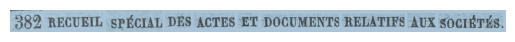

In [199]:
import cv2

def resize_crop(crop, max_h, max_w, color):
    h, w = crop.shape[:2]
    top = (max_h - h) // 2
    bottom = max_h - h - top
    left = 0
    right = max_w - w

    if crop.ndim == 2 or (crop.ndim == 3 and crop.shape[2] == 1):
        val = int(color if np.isscalar(color) else int(np.mean(color)))
    else:
        r, g, b = map(int, color)
        val = (b, g, r)
    return cv2.copyMakeBorder(crop, top, bottom, left, right, cv2.BORDER_CONSTANT, value=val)

def get_most_color(crop):
    pixels = crop.reshape(-1, 3)
    colors, counts = np.unique(pixels, axis=0, return_counts=True)
    most_common_rgb = tuple(colors[counts.argmax()][::-1])
    return most_common_rgb

lines_collage = []

for idx, crop_line_image in enumerate(cropped_images):
    h, w = None, None
    for crop in crop_line_image:
        if h is None:
            h, w = crop.shape[:2]
            color = get_most_color(crop)
        else:
            h_new = crop.shape[0]
            h = max(h, h_new)

    padded_line = []

    for crop in crop_line_image:
        padded_image = resize_crop(crop, h, crop.shape[1] + 10, color=color)
        padded_line.append(padded_image)
    
    combined_line_image = np.hstack(padded_line)

    if idx == 0:
        print("First line image as example:")
        plt.imshow(combined_line_image)
        plt.axis('off')
        plt.show()

    lines_collage.append(combined_line_image)




## Use qwen for OCR on the line image 

In [202]:
import io
from PIL import Image


model = Qwen2_5_VLForConditionalGeneration.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", torch_dtype="auto", device_map="auto")

processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", min_pixels=128 * 28 * 28, max_pixels=2056 * 28 * 28)

qwen_text_transcription = []

for crop in lines_collage:
        crop = base64.b64encode(cv.imencode('.png', crop)[1]).decode('utf-8')
        prompt = (f"Transcribe all text and numbers in the image. Ignore other text artefacts.")
        message = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": f"data:image/png;base64,{crop}"},
                    {"type": "text", "text": prompt},
                ],
            }
        ]

        img_bytes = base64.b64decode(crop)
        img = Image.open(io.BytesIO(img_bytes))
        
        text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(message)
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )
        inputs = inputs.to("cuda")

        generated_ids = model.generate(**inputs, max_new_tokens=120)
        generated_ids_trimmed = [
            out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        text = processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )

        text = text[0].split(' ')
        print(text)
        qwen_text_transcription.append(text)

Loading checkpoint shards: 100%|██████████| 5/5 [00:01<00:00,  3.18it/s]


['382', 'RECUEIL', 'SPÉCIAL', 'DES', 'ACTES', 'ET', 'DOCUMENTS', 'RELATIFS', 'AUX', 'SOCIÉTÉS.']
['Mouvement', 'du', 'portefeuille']
['Il', 'existait', 'en', 'portefeuille,', 'au', '31', 'décembre', '1882.', '2.399', 'effets,', 'ensemble', 'fr.', '755,677', '52']
['Il', 'est', 'entré', 'en', '1883', '54,903', '20,471,283', '23']
['57,302', '21,226,960', '75']
['Il', 'est', 'sorti', 'en', '1883.', '55,262', '20,640,954', '26']
['En', 'portefeuille', 'au', '31', 'décembre', '1883', '2,040', 'fr.', '586,009', '49']
['Compte', 'de', 'profits', 'et', 'pertes.']
['Le', 'solde', 'créditeur', 'de', 'ce', 'compte,', 'au', '31', 'décembre', '1883,', 'est', 'de', 'fr.', '91,763', '82']
['A', 'déduire']
['1°', 'Frais', 'généraux', 'fr', '28,740', '05']
['2°', 'Réescompte', 'du', 'portefeuille.', '5,262', '18', '35,502', '23']
['3°', 'Fonds', 'de', 'prévision', '(patente,', 'etc.)', '1,500']
['Bénéfices', 'nets.', '56,261', '59']
['5', 'p.', 'c.', 'à', 'la', 'réserve', 'statutaire', '2,813', '08']


## Clear VRAM otherwise it stays in mem and offload to cpu

In [203]:
import torch 
import gc

del model
del processor

torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()

120

In [207]:
from rapidfuzz import fuzz

tesseract_line_one = tesseract_transcribed_texts[2]
qwen_line_one = qwen_text_transcription[2]


class MatchQwenToTesseract:
    
    def __init__(self, tesseract_line, qwen_line):
        self.tesseract_line = tesseract_line
        self.qwen_line = qwen_line

    def match_lines(self):
        lenght_tesseract = len(self.tesseract_line)
        lenght_qwen = len(self.qwen_line)

        corrected_words_with_bounding_box = []

        if lenght_tesseract != lenght_qwen:
            print(tesseract_line_one)
            print(qwen_line_one)










        else:
           # Simple matching based on the best score, works like a charm
           for word in self.qwen_line:
                best_match = None
                best_score = 0
                for tesseract_word in self.tesseract_line:
                    score = fuzz.ratio(word, tesseract_word[0])
                    if score > best_score:
                        best_score = score
                        coord = tesseract_word[1]
                        best_match = tesseract_word[0]
                
                if best_match is not None:
                    corrected_words_with_bounding_box.append((word, coord))


        return corrected_words_with_bounding_box


match_qwen_to_tesseract = MatchQwenToTesseract(tesseract_line_one, qwen_line_one)
corrected_linked_words = match_qwen_to_tesseract.match_lines()
print("Corrected linked words:" + str(corrected_linked_words))

[('Il existait', (556, 678, 761, 745)), ('en', (761, 683, 828, 740)), ('portefeuille,', (828, 678, 1085, 745)), ('au', (1090, 683, 1162, 735)), ('51', (1157, 678, 1224, 735)), ('décembre', (1239, 678, 1440, 724)), ('4882,', (1450, 673, 1579, 724)), ('2.399', (2206, 668, 2345, 719)), ('effets,', (2355, 658, 2499, 724)), ('ensemble', (2509, 663, 2710, 714)), ('fr.', (2859, 673, 2921, 719)), ('755.677', (3096, 668, 3281, 719)), ('159', (3270, 668, 3353, 719))]
['Il', 'existait', 'en', 'portefeuille,', 'au', '31', 'décembre', '1882.', '2.399', 'effets,', 'ensemble', 'fr.', '755,677', '52']
Corrected linked words:[]
